<a href="https://colab.research.google.com/github/hetalsharmaaa/perzonix/blob/main/shoppersintent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

%matplotlib inline
sns.set(style="whitegrid")

url = "https://raw.githubusercontent.com/sharmaroshan/Online-Shoppers-Purchasing-Intention/master/online_shoppers_intention.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()
df.describe(include="all")
df["Revenue"].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,proportion
Revenue,
False,0.845255
True,0.154745


In [4]:
df.isnull().sum()
df.isnull().sum().sum()

np.int64(0)

In [5]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Duplicate rows: 125
Shape after dropping duplicates: (12205, 18)


In [6]:
df.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [7]:
numeric_cols = ["Administrative", "Administrative_Duration", "Informational",
                 "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
                 "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

df[numeric_cols].describe()

print((df["Administrative_Duration"] < 0).sum())
print((df["BounceRates"] > 1).sum())
print((df["ExitRates"] > 1).sum())

0
0
0


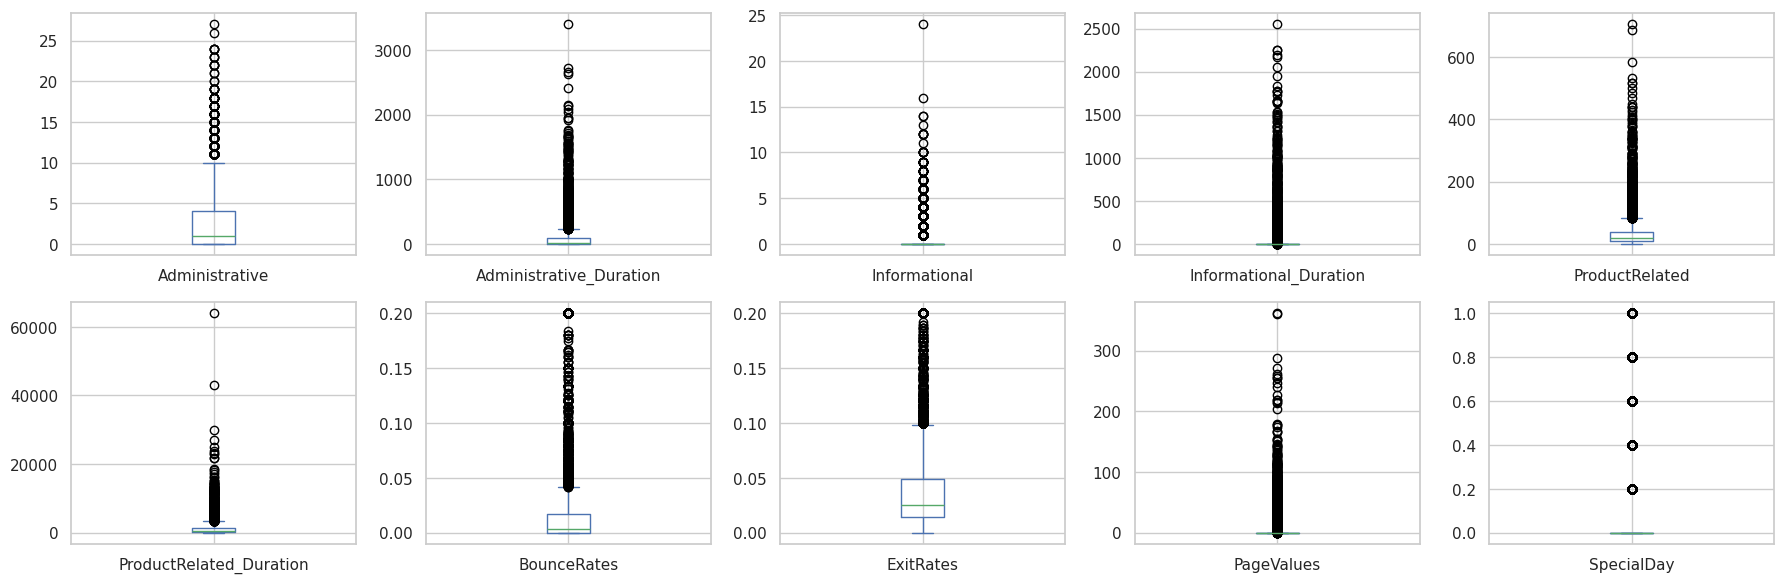

In [8]:
import matplotlib.pyplot as plt
df[numeric_cols].plot(kind="box", subplots=True, layout=(2,5), figsize=(18,6))
plt.tight_layout()
plt.show()

In [9]:
for col in ["Month", "VisitorType", "Weekend", "Revenue"]:
    print(col, ":", df[col].unique())

Month : ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
VisitorType : ['Returning_Visitor' 'New_Visitor' 'Other']
Weekend : [False  True]
Revenue : [False  True]


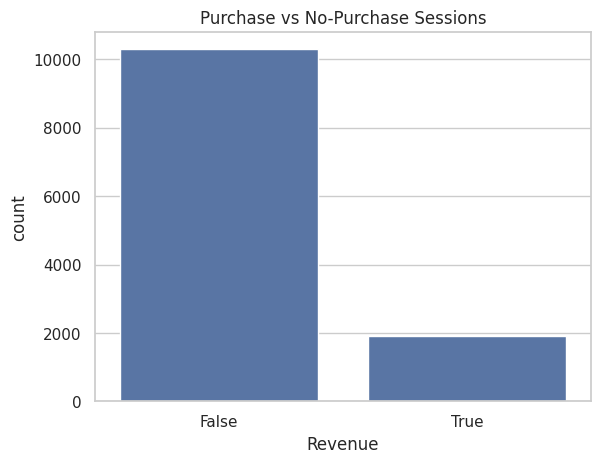

Revenue
False    84.367063
True     15.632937
Name: proportion, dtype: float64


In [10]:
sns.countplot(x="Revenue", data=df)
plt.title("Purchase vs No-Purchase Sessions")
plt.show()

print(df["Revenue"].value_counts(normalize=True) * 100)

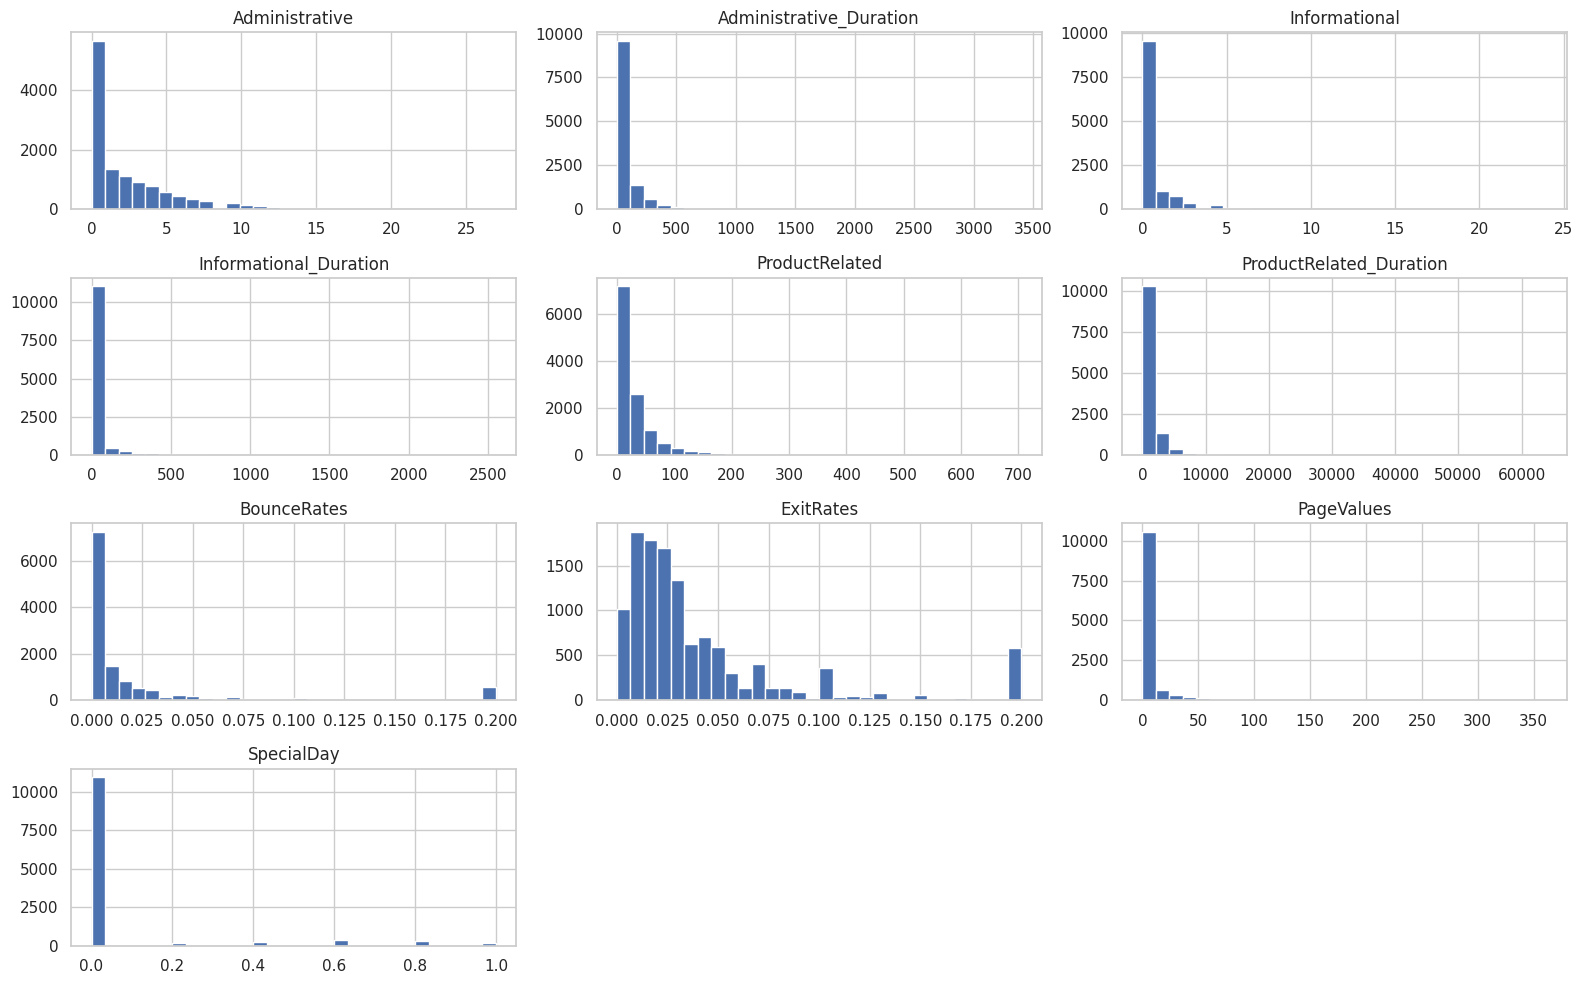

In [11]:
numeric_cols = ["Administrative", "Administrative_Duration", "Informational",
                 "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
                 "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

df[numeric_cols].hist(bins=30, figsize=(16,10))
plt.tight_layout()
plt.show()

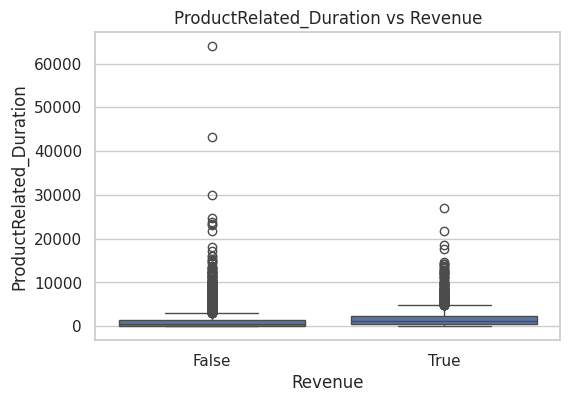

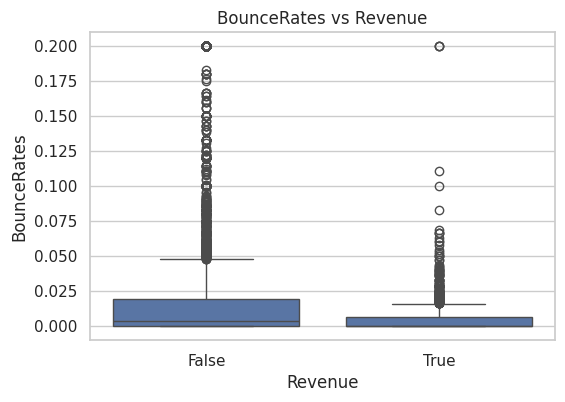

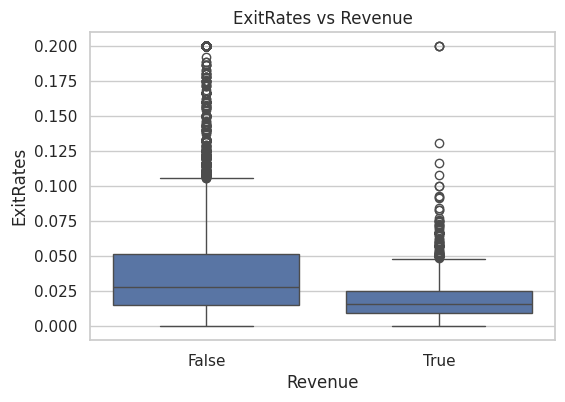

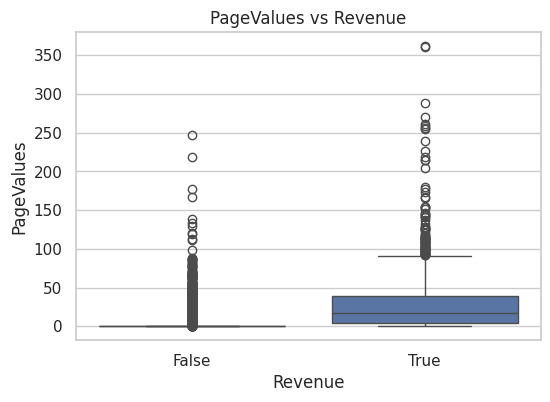

In [12]:
for col in ["ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Revenue", y=col, data=df)
    plt.title(f"{col} vs Revenue")
    plt.show()